### 7.1

In [12]:
import numpy as np
from numpy import linalg as la

np.set_printoptions(suppress=True)
A = np.array([1,2,3,0,-4,1,0,3,-1]).reshape(3,3)

determ = la.det(A)
print(A)
print(f"determinant: {determ}")

b = np.array([2,2,1])
invers = la.inv(A)
sol = invers@b #solution can also be solved using la.solve
print(sol)

#orthogonal if transpose = inverse

print(f"A is orthogonal: {np.allclose(A.T, la.inv(A))}")

lambdav, v = la.eig(A)
print(f"eigenvalues: {lambdav}")
print(f"eigenvectors: \n{v}")



[[ 1  2  3]
 [ 0 -4  1]
 [ 0  3 -1]]
determinant: 1.0
[ 38.  -3. -10.]
A is orthogonal: False
lambda is: [ 1.         -4.79128785 -0.20871215]
eigenvectors: 
[[ 1.         -0.05055961  0.94256676]
 [ 0.         -0.78318743 -0.08518794]
 [ 0.          0.6197267  -0.32297201]]


### 7.3

In [25]:
import numpy as np
from numpy import linalg as la


def Ex(alpha):
    ex = np.array([1,0,0,0,\
               np.cos(np.deg2rad(alpha)),np.sin(np.deg2rad(alpha)),\
              0,-np.sin(np.deg2rad(alpha)),np.cos(np.deg2rad(alpha))]).reshape(3,3)
    return ex
def Ey(beta):
    ey = np.array([np.cos(np.deg2rad(beta)),0,-np.sin(np.deg2rad(beta)),\
              0,1,0, np.sin(np.deg2rad(beta)),0,np.cos(np.deg2rad(beta))]).reshape(3,3)

    return ey

def Ez(gamma):
    Ez = np.array([np.cos(np.deg2rad(gamma)),np.sin(np.deg2rad(gamma)),0,\
              -np.sin(np.deg2rad(gamma)),np.cos(np.deg2rad(gamma)),0\
              ,0,0,1]).reshape(3,3)
    return Ez

matrix = Ez(180-123)@Ey(90-27.4)@Ez(192.25)

print(matrix)

## if it is a rotation matrix then its determinant is 1 and the transpose equals the inverse 
det = la.det(matrix)
transpose = la.matrix_transpose(matrix)
inv = la.inv(matrix)
if det ==1 and transpose.all() == inv.all():
    print("it is the rotation matrix")
else:
    print("not the same")

if la.eigvals(matrix).all()==1:
    print("eval = 1")
else:
    print("eval is not 1")

alp = 192.25
delt = 27.4
v = np.array([-0.86760081, -0.1883746, 0.46019978])
vec = np.array([np.cos(np.deg2rad(delt))*np.cos(np.deg2rad(alp)),np.cos(np.deg2rad(delt))*np.sin(np.deg2rad(alp)),np.sin(np.deg2rad(delt))])
normal = la.vector_norm(v)
if v.all()==vec.all():
    if np.isclose(normal, 1, atol=1e-6) ==1: ##had to get a value close to 1 because the normal is 0.9999...
        print("v follows the equation and its norm = 1")

print(np.round(matrix@v))

[[-0.06698874 -0.87275577 -0.48353891]
 [ 0.49272847 -0.45034696  0.74458463]
 [-0.86760081 -0.1883746   0.46019978]]
it is the rotation matrix
eval = 1
v follows the equation and its norm = 1
[ 0. -0.  1.]


### 7.5

[ 2.18582332e+02 -5.51003146e+02  5.65812237e+02 -3.13633556e+02
  1.04544074e+02 -2.19331359e+01  2.91867714e+00 -2.39059756e-01
  1.09925609e-02 -2.17117476e-04]


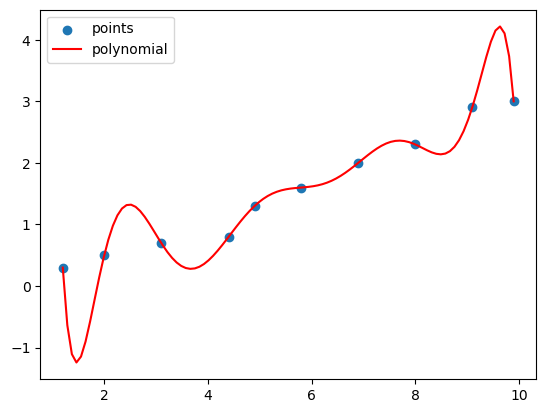

In [39]:
import numpy as np
from numpy import linalg as la
import matplotlib.pyplot as plt


x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])
n = len(x)
## we need a matrix A that is multiplied by x to get y. So that means that A is an n by n matrix
A = np.zeros((n,n))
for i in range(n):
    for j in range(n):
        A[i][j]=x[i]**j  ## this gives the matrix with x polynomials   

solved = la.solve(A,y)
print(solved)

##for plotting:
x_vals = np.linspace(np.min(x),np.max(x),100)
y_vals = np.zeros_like(x_vals)

for i in range(len(solved)):
    y_vals = y_vals+ (solved[i]*x_vals**i)


plt.scatter(x,y,label = "points")
plt.plot(x_vals,y_vals, color="r",label = "polynomial")
plt.legend()
plt.show()

### 7.6

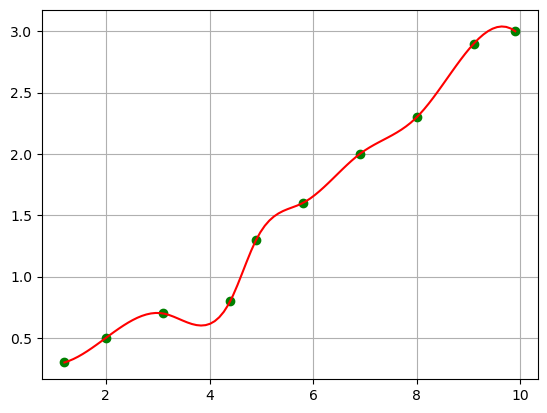

In [45]:
import numpy as np
from numpy import linalg as la
import matplotlib.pyplot as plt
from scipy import interpolate as ip


x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])
f = ip.interp1d(x, y, kind='cubic')

newx =  np.linspace(np.min(x),np.max(x),100) # notice outside the original domain
newy = f(newx)

fig = figure()
frame = fig.add_subplot(1,1,1)
frame.plot(x, y, 'go')
frame.plot(newx, newy, 'r')
frame.grid(True)
plt.show()

2. 7.5's graph looks quartic; this is cubic

In [58]:
import numpy as np
from numpy import linalg as la
import matplotlib.pyplot as plt
from scipy import interpolate as ip

class interpolation:
    def __init__(self,x,y):
        self.x = np.array(x)
        self.y = np.array(y)
        self.n = len(x)

    def linear(self,x_val):
        f = ip.interp1d(self.x, self.y, kind='linear')
        return f(x_val)

    def polynomial(self,x_val):
        A = np.zeros((self.n,self.n))
        for i in range(self.n):
            for j in range(self.n):
                A[i][j]=self.x[i]**j  ## this gives the matrix with x polynomials   

        solved = la.solve(A,y)
        y_val = np.zeros_like(x_val)
        for i in range(len(solved)):
            y_val = y_val+ (solved[i]*x_val**i)
        return y_val

    def spline(self,x_val):
        cubic = ip.CubicSpline(self.x,self.y)

        return cubic(x_val)

    def choose(self,xhat,method):
        if method == 'linear':
            return self.linear(xhat)
        elif method == "poly":
            return self.polynomial(xhat)
        elif method =="spline":
            return self.spline(xhat)
        else:
            print("not linear, polynomial, or spline???")

xhatinput = input("enter x-hat: ")
xhat =float(xhatinput)
method = input("enter the method (linear, poly, or spline):")
x = [1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9]
y = [0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0]

interp = interpolation(x, y)
yhat = interp.choose(xhat,method)
print(yhat)

enter x-hat:  5.5
enter the method (linear, poly, or spline): poly


1.5702983235861439


### 7.7

In [59]:
import numpy as np

def bilinearIP(I, col, row): # Make it X, Y compatible
    '''I is a two dimensional array and iF,jF is the position at
       which we want to interpolate. 'iF' must be bigger or equal to 0 and
       smaller than the highest index of I in i. The same applies for jF'''
    rowlen, collen= I.shape
    i = int(row)
    j = int(col)
    if row - i == 0 and col - j == 0:  # Falls exactly on a gridpoint
        return I[i,j]

    inbounds = (0 <= j <= collen-1) and (0 <= i <= rowlen-1)
    if not inbounds:
        Iintp = None
    else:
        mu =  row - i
        Lambda = col - j
        # If we are at the last pixel at the right or bottom, then there
        # is not a neighbour, so we take the pixel itself as the neighbour
        I0 = I[i,j]
        I1 = I[i,min(j+1,collen-1)]
        I2 = I[min(i+1,rowlen-1),j]
        I3 = I[min(i+1,rowlen-1),min(j+1,collen-1)]
        Iintp = (1-Lambda)*(1-mu)*I0 + Lambda*(1-mu)*I1 + mu*(1-Lambda)*I2 + Lambda*mu*I3
    return(Iintp)

I = np.array([[2.0,4.1], [2.5,3.8]])
print(I)

row_y = 0.7 # Row position is y value
col_x = 0.2  # Column position is x value

Iintp = bilinearIP(I, col_x, row_y)
if Iintp:
    print(f"The interpolated intensity at i,j={row_y},{col_x} => x, y={col_x}{row_y} is {Iintp:.6f}")
else:
    print("One of the indices was outside the limits")

[[2.  4.1]
 [2.5 3.8]]
The interpolated intensity at i,j=0.7,0.2 => x, y=0.20.7 is 2.658000


### 7.10

[69.93805484 64.13233513]


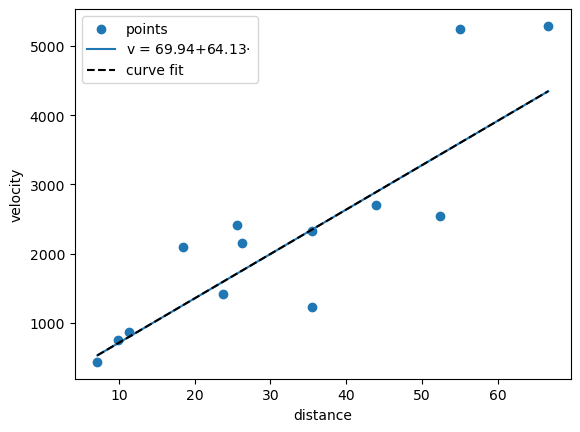

In [85]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import leastsq, curve_fit


data = [
   18.49,     2094.75,    0.3,           100,
   35.48,     2320.87,    2.2,           120,
   35.48,     1224.9,     3.0,           80,
   11.34,     872.13,     1.2,           80,
   7.12,      432.2,      0.4,           70,
   9.82,      751,        0.3,           75,
   23.66,     1410,       2.3,           70,
   44,        2700,       4.0,           110,
   66.7,      5292,       5.3,           120,
   52.4,      2550,       5.2,           100,
   55,        5253,       6.1,           150,
   25.6,      2419,       3.2,           110,
   26.19,     2158,       2.8,           110
]

data_array = np.array(data).reshape(-1,4)
distance = data_array[:,0]
vel = data_array[:,1]
vel_error=data_array[:,3]
mu = np.mean(distance)
sigma = np.std(distance)

def f(x, beta):              # Our model
    beta0, beta1 = beta      # Unpack beta hat
    return beta0 + beta1*x

def residuals(beta,dist,vel,vel_err):
    return (vel-(beta[0]+beta[1]*dist))/vel_err

beta = (2,1) #it needs a value here, so i randomyl chose 2 and 1 
betas = leastsq(residuals,beta,args=(distance, vel, vel_error))
optimized = betas[0]
print(optimized)


def model(x, beta0, beta1):
    """The model with parameters a and b. Note that for the Hubble relation we fix a to 0.0"""
    return beta0 + beta1*x
# Do the fitting
beta, pcov = curve_fit(model, distance, vel,sigma=vel_error)
X = np.array([distance.min(),distance.max()])
Y = model(X, beta[0], beta[1])


from matplotlib.pyplot import figure, show

x_plot = (np.linspace(min(distance),max(distance),100))
fig = figure()
frame = fig.add_subplot(1,1,1)
frame.scatter(distance, vel, marker='o', label="points")
frame.plot(x_plot,optimized[0]+optimized[1]*x_plot,label = f"v = {optimized[0]:.2f}+{optimized[1]:.2f}$\cdot$ ")
frame.set_xlabel('distance')
frame.set_ylabel('velocity')

frame.plot(X, Y, color='k',label = "curve fit",ls = "--")
frame.legend()
show()